In [102]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import re
import hazm 

In [2]:
df = pd.read_csv('data/filtered_laugh_reactions.csv')

df.tail()

,Text,Top Reaction,Top Reaction Count,Views,Date
28310,آقا ما می‌خواستیم یکیو بپیچونیم گفتیم کارتمون ...,🤣,1057,32546,2025-07-15
28311,"عربه تو مشهد پا میشه میره فست فودی میپرسه ""ما ...",🤣,971,26453,2025-07-15
28312,این چیزهایی که ما الان بهش می‌گیم «رابطه‌ی سمی...,🤣,678,22388,2025-07-15
28313,داشتم سالاد میخوردم ، همکار وجترینم اومد کنارم...,🤣,939,18329,2025-07-15
28314,🔵استقلال در اولین مسابقه تدارکاتی خود در اردوی...,🤣,135,9180,2025-07-15


In [3]:
df.iloc[0:10000]

,Text,Top Reaction,Top Reaction Count,Views,Date
0,سجاد غریبی بیشتر بدرد خندوانه میخوره × نولان...,😁,1258,92414,2022-08-01
1,کاش سجاد غریبی رو ممنون الخروج کنن که دیگه نتو...,😁,1417,92756,2022-08-01
2,میگن سجاد غریبی وسطای مسابقه گفته: قبول نیس، ا...,😁,1671,96096,2022-08-01
3,به کیسه بوکس مشت میزنی برمیگرده، سجاد غریبی می...,😁,1174,93269,2022-08-01
4,‏اگه جای سجاد غریبی بودم حالا که کتکه رو خورده...,😁,1016,86528,2022-08-01
...,...,...,...,...,...
9995,وسط این دویدن و نرسیدن‌ها یادم افتاد سال ۳رزید...,😁,2743,109184,2023-09-28
9996,یه مهمون داشتم شیرازی سفت. لیمو رو هرچی فشار م...,😁,3150,96031,2023-09-28
9997,پیتزای محبوبم رو سفارش دادیم. شوهرم یه برش خور...,😁,3070,97880,2023-09-28
9998,امروز یه جلسه کاری مهم داشتم کت شلوار پوشیدم و...,😁,1906,87644,2023-09-28


In [4]:
uniqe_recation_count = df['Top Reaction Count'].unique()
len(uniqe_recation_count)

3806

In [5]:
uniqe_recation_count.sort()


In [54]:
x =list(pd.DataFrame(df['Top Reaction Count'].value_counts()).index)

In [55]:
y = list(pd.DataFrame(df['Top Reaction Count'].value_counts()).iloc[:,0])

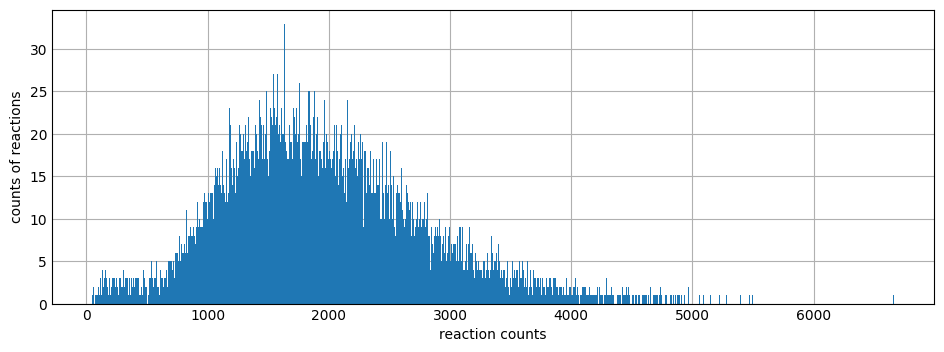

In [56]:
plt.style.use('_mpl-gallery')


plt.figure(figsize=(9, 3))

plt.bar(x, y, width=5)
plt.xlabel('reaction counts')
plt.ylabel("counts of reactions")


plt.show()

In [65]:
reactions1000_sum = []
for i in range(0, 4000, 1000): 
    reaction_sum = ((df['Top Reaction Count'] >= i) & (df['Top Reaction Count'] <= i +1000)).sum()
    print(i)
    reactions1000_sum.append(reaction_sum)



reactions1000_sum
    




0
1000
2000
3000


[2442, 14150, 9348, 2128]

In [59]:
x = [2442, 14150, 9348,2128]
y = ['<1000', '1000> and <2000', '<2000 and >3000','<3000 and >4000']

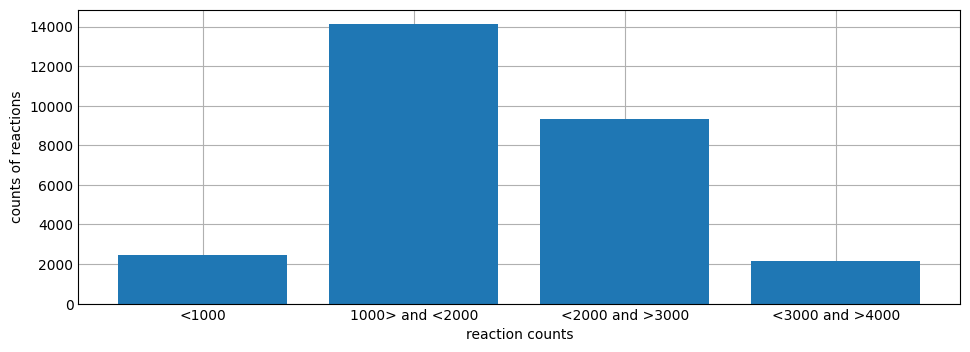

In [60]:
plt.style.use('_mpl-gallery')


plt.figure(figsize=(9, 3))

plt.bar(y, reactions1000_sum)
plt.xlabel('reaction counts')
plt.ylabel("counts of reactions")


plt.show()

In [61]:
reactions500_sum = []
for i in range(0, 4000, 500): 
    reaction_sum = ((df['Top Reaction Count'] >= i) & (df['Top Reaction Count'] <= i +500)).sum()
    reactions500_sum.append(reaction_sum)



reactions500_sum
    

[484, 1962, 6320, 7844, 5938, 3419, 1500, 631]

In [62]:
 y = ['<500', '>500 and <1000', '>1000 and <1500','>1500 and <2000',' >2000 and <2500', '>2500 and <3000', '>3000 and <3500', '>3500 and <4000']

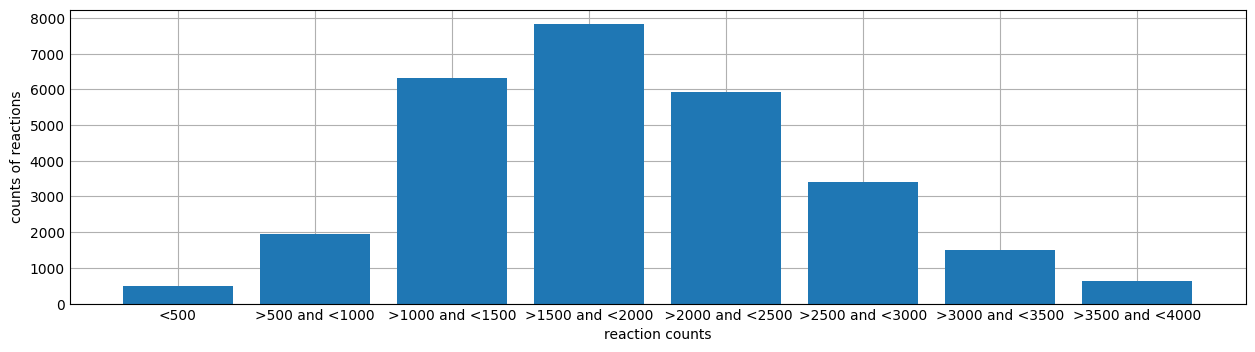

In [63]:
plt.style.use('_mpl-gallery')


plt.figure(figsize=(12, 3))

plt.bar(y, reactions500_sum)
plt.xlabel('reaction counts')
plt.ylabel("counts of reactions")


plt.show()

In [69]:
((df['Top Reaction Count'] >= 2001) & (df['Top Reaction Count'] <= 3000)).sum()


9335

In [70]:
main_reaction_results = [8757, 7830,9335 ]
y = ['<=1500', '>1500 and <= 2000', '>2000 and <=3000']

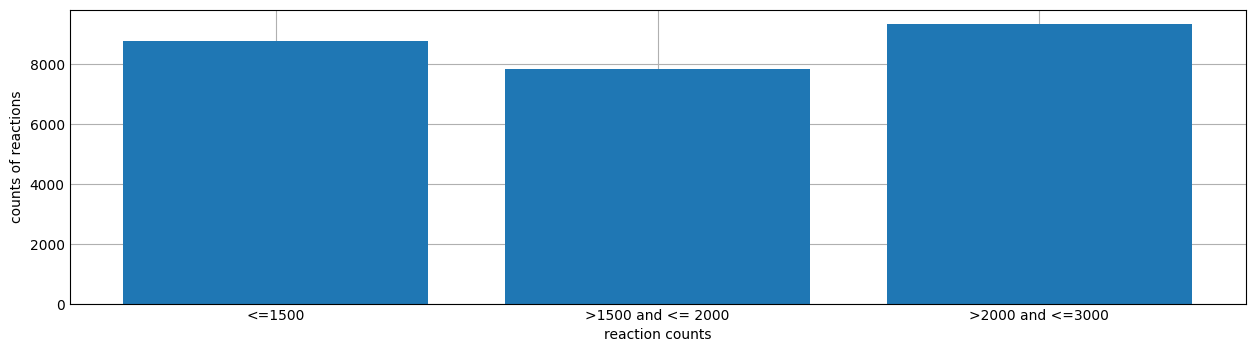

In [71]:
plt.style.use('_mpl-gallery')


plt.figure(figsize=(12, 3))

plt.bar(y, main_reaction_results)
plt.xlabel('reaction counts')
plt.ylabel("counts of reactions")


plt.show()

In [73]:
df = df[df['Top Reaction Count']<=3000]

In [75]:
df

,Text,Top Reaction,Top Reaction Count,Views,Date
0,سجاد غریبی بیشتر بدرد خندوانه میخوره × نولان...,😁,1258,92414,2022-08-01
1,کاش سجاد غریبی رو ممنون الخروج کنن که دیگه نتو...,😁,1417,92756,2022-08-01
2,میگن سجاد غریبی وسطای مسابقه گفته: قبول نیس، ا...,😁,1671,96096,2022-08-01
3,به کیسه بوکس مشت میزنی برمیگرده، سجاد غریبی می...,😁,1174,93269,2022-08-01
4,‏اگه جای سجاد غریبی بودم حالا که کتکه رو خورده...,😁,1016,86528,2022-08-01
...,...,...,...,...,...
28310,آقا ما می‌خواستیم یکیو بپیچونیم گفتیم کارتمون ...,🤣,1057,32546,2025-07-15
28311,"عربه تو مشهد پا میشه میره فست فودی میپرسه ""ما ...",🤣,971,26453,2025-07-15
28312,این چیزهایی که ما الان بهش می‌گیم «رابطه‌ی سمی...,🤣,678,22388,2025-07-15
28313,داشتم سالاد میخوردم ، همکار وجترینم اومد کنارم...,🤣,939,18329,2025-07-15


In [94]:
df['Target'] = None
df.loc[df['Top Reaction Count'] <= 1500, 'Target'] = 1
df

/tmp/ipykernel_967/911477358.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Target'] = None


,Text,Top Reaction,Top Reaction Count,Views,Date,Target
0,سجاد غریبی بیشتر بدرد خندوانه میخوره × نولان...,😁,1258,92414,2022-08-01,1
1,کاش سجاد غریبی رو ممنون الخروج کنن که دیگه نتو...,😁,1417,92756,2022-08-01,1
2,میگن سجاد غریبی وسطای مسابقه گفته: قبول نیس، ا...,😁,1671,96096,2022-08-01,None
3,به کیسه بوکس مشت میزنی برمیگرده، سجاد غریبی می...,😁,1174,93269,2022-08-01,1
4,‏اگه جای سجاد غریبی بودم حالا که کتکه رو خورده...,😁,1016,86528,2022-08-01,1
...,...,...,...,...,...,...
28310,آقا ما می‌خواستیم یکیو بپیچونیم گفتیم کارتمون ...,🤣,1057,32546,2025-07-15,1
28311,"عربه تو مشهد پا میشه میره فست فودی میپرسه ""ما ...",🤣,971,26453,2025-07-15,1
28312,این چیزهایی که ما الان بهش می‌گیم «رابطه‌ی سمی...,🤣,678,22388,2025-07-15,1
28313,داشتم سالاد میخوردم ، همکار وجترینم اومد کنارم...,🤣,939,18329,2025-07-15,1


In [96]:
df.loc[(df['Top Reaction Count'] >= 1501) & (df['Top Reaction Count'] <= 2000), 'Target'] = 2
df

,Text,Top Reaction,Top Reaction Count,Views,Date,Target
0,سجاد غریبی بیشتر بدرد خندوانه میخوره × نولان...,😁,1258,92414,2022-08-01,1
1,کاش سجاد غریبی رو ممنون الخروج کنن که دیگه نتو...,😁,1417,92756,2022-08-01,1
2,میگن سجاد غریبی وسطای مسابقه گفته: قبول نیس، ا...,😁,1671,96096,2022-08-01,2
3,به کیسه بوکس مشت میزنی برمیگرده، سجاد غریبی می...,😁,1174,93269,2022-08-01,1
4,‏اگه جای سجاد غریبی بودم حالا که کتکه رو خورده...,😁,1016,86528,2022-08-01,1
...,...,...,...,...,...,...
28310,آقا ما می‌خواستیم یکیو بپیچونیم گفتیم کارتمون ...,🤣,1057,32546,2025-07-15,1
28311,"عربه تو مشهد پا میشه میره فست فودی میپرسه ""ما ...",🤣,971,26453,2025-07-15,1
28312,این چیزهایی که ما الان بهش می‌گیم «رابطه‌ی سمی...,🤣,678,22388,2025-07-15,1
28313,داشتم سالاد میخوردم ، همکار وجترینم اومد کنارم...,🤣,939,18329,2025-07-15,1


In [97]:
df.loc[(df['Top Reaction Count'] >= 2001) & (df['Top Reaction Count'] <= 3000), 'Target'] = 3
df

,Text,Top Reaction,Top Reaction Count,Views,Date,Target
0,سجاد غریبی بیشتر بدرد خندوانه میخوره × نولان...,😁,1258,92414,2022-08-01,1
1,کاش سجاد غریبی رو ممنون الخروج کنن که دیگه نتو...,😁,1417,92756,2022-08-01,1
2,میگن سجاد غریبی وسطای مسابقه گفته: قبول نیس، ا...,😁,1671,96096,2022-08-01,2
3,به کیسه بوکس مشت میزنی برمیگرده، سجاد غریبی می...,😁,1174,93269,2022-08-01,1
4,‏اگه جای سجاد غریبی بودم حالا که کتکه رو خورده...,😁,1016,86528,2022-08-01,1
...,...,...,...,...,...,...
28310,آقا ما می‌خواستیم یکیو بپیچونیم گفتیم کارتمون ...,🤣,1057,32546,2025-07-15,1
28311,"عربه تو مشهد پا میشه میره فست فودی میپرسه ""ما ...",🤣,971,26453,2025-07-15,1
28312,این چیزهایی که ما الان بهش می‌گیم «رابطه‌ی سمی...,🤣,678,22388,2025-07-15,1
28313,داشتم سالاد میخوردم ، همکار وجترینم اومد کنارم...,🤣,939,18329,2025-07-15,1


In [98]:
df['Target'].value_counts()

Target
3    9335
1    8757
2    7830
Name: count, dtype: int64

In [100]:
df = df[['Text', 'Target']]
df

,Text,Target
0,سجاد غریبی بیشتر بدرد خندوانه میخوره × نولان...,1
1,کاش سجاد غریبی رو ممنون الخروج کنن که دیگه نتو...,1
2,میگن سجاد غریبی وسطای مسابقه گفته: قبول نیس، ا...,2
3,به کیسه بوکس مشت میزنی برمیگرده، سجاد غریبی می...,1
4,‏اگه جای سجاد غریبی بودم حالا که کتکه رو خورده...,1
...,...,...
28310,آقا ما می‌خواستیم یکیو بپیچونیم گفتیم کارتمون ...,1
28311,"عربه تو مشهد پا میشه میره فست فودی میپرسه ""ما ...",1
28312,این چیزهایی که ما الان بهش می‌گیم «رابطه‌ی سمی...,1
28313,داشتم سالاد میخوردم ، همکار وجترینم اومد کنارم...,1


In [101]:
df.head()

,Text,Target
0,سجاد غریبی بیشتر بدرد خندوانه میخوره × نولان...,1
1,کاش سجاد غریبی رو ممنون الخروج کنن که دیگه نتو...,1
2,میگن سجاد غریبی وسطای مسابقه گفته: قبول نیس، ا...,2
3,به کیسه بوکس مشت میزنی برمیگرده، سجاد غریبی می...,1
4,‏اگه جای سجاد غریبی بودم حالا که کتکه رو خورده...,1


In [103]:
def filter_emojis(text):
    important_emojis = ['😂', '😐', '😑', '😒', '🙂', '😔', '🚶']
    return ''.join([ch for ch in text if (ch.isalnum() or ch.isspace() or ch in important_emojis)])


In [105]:
normalizer = hazm.Normalizer()
stopwords = set(hazm.stopwords_list())

def clean_text_pipeline(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)

    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    text = re.sub(r'(.)\1{2,}', r'\1', text)

    text = re.sub(r'[^آ-یa-zA-Z0-9\s\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF]', '', text)

    text = filter_emojis(text)
    text = text.replace('ي', 'ی').replace('ك', 'ک')
    
    text = re.sub(r'[‌\u200c]', ' ', text)  
 
    text = re.sub(r'\b[a-zA-Z]+\b', '', text)
    text = re.sub(r'[a-zA-Z]+', '', text)



  


    text = re.sub(r'\s+', ' ', text).strip()


    text = normalizer.normalize(text)





    tokens = hazm.word_tokenize(text)
    tokens = [w for w in tokens if w not in stopwords]

    return ' '.join(tokens)


In [107]:
df['clened_text'] = df['Text'].apply(clean_text_pipeline)

/tmp/ipykernel_967/1456683005.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clened_text'] = df['Text'].apply(clean_text_pipeline)


In [110]:
for i in range(5):
    print(f"\n اصل: {df['Text'].iloc[i]}")
    print(f" تمیزشده: {df['clened_text'].iloc[i]}")


 اصل: سجاد غریبی بیشتر بدرد خندوانه میخوره   × نولانی ×  @OfficialPersianTwitter
 تمیزشده: سجاد غریبی بدرد خندوانه میخوره نولانی

 اصل: کاش سجاد غریبی رو ممنون الخروج کنن که دیگه نتونه بره جایی آبروریزی کنه  × Ali ×  @OfficialPersianTwitter
 تمیزشده: کاش سجاد غریبی ممنون الخروج کنن دیگه نتونه بره آبروریزی کنه

 اصل: میگن سجاد غریبی وسطای مسابقه گفته: قبول نیس، این مشت میزنه   × 𝐒𝐨𝐛𝐡𝐚𝐧 𝐙𝐚𝐫𝐠𝐡𝐚𝐦𝐢 ×  @OfficialPersianTwitter
 تمیزشده: میگن سجاد غریبی وسطای مسابقه قبول نیس مشت میزنه

 اصل: به کیسه بوکس مشت میزنی برمیگرده، سجاد غریبی میرفت دیگه برنمیگشت ...   × $|-|@|-|R@M  ×  @OfficialPersianTwitter
 تمیزشده: کیسه بوکس مشت می‌زنی برمیگرده سجاد غریبی می‌رفت دیگه برنمیگشت

 اصل: ‏اگه جای سجاد غریبی بودم حالا که کتکه رو خورده‌م فورا برای گرفتن دیه اقدام می‌کردم. فیلمشم هست یارو نمی‌تونه انکار کنه.  × تارانزینو ×  @OfficialPersianTwitter
 تمیزشده: اگه سجاد غریبی بودم کتکه خوردهم فورا گرفتن دیه اقدام می‌کردم فیلمشم هست یارو نمیتونه انکار کنه تارانزینو


In [111]:
df['clened_text'] = df['clened_text'].str.replace(r'\bیه\b', '', regex=True)
df['clened_text'] = df['clened_text'].str.replace(r'ها', '', regex=True)
df['clened_text'] = df['clened_text'].str.replace(r'های', '', regex=True)



/tmp/ipykernel_967/2913032328.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clened_text'] = df['clened_text'].str.replace(r'\bیه\b', '', regex=True)
/tmp/ipykernel_967/2913032328.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clened_text'] = df['clened_text'].str.replace(r'ها', '', regex=True)
/tmp/ipykernel_967/2913032328.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

In [115]:
df.to_csv('data/cleaned_data.csv', index=False)